In [13]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## Position of a star

You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above

In [14]:
N = 10
mu = 1.
sigma = 0.2

gauss = norm(mu, sigma)

In [15]:
x = gauss.rvs(N)
xgrid = np.linspace(mu-4*sigma, mu+4*sigma, 10000)

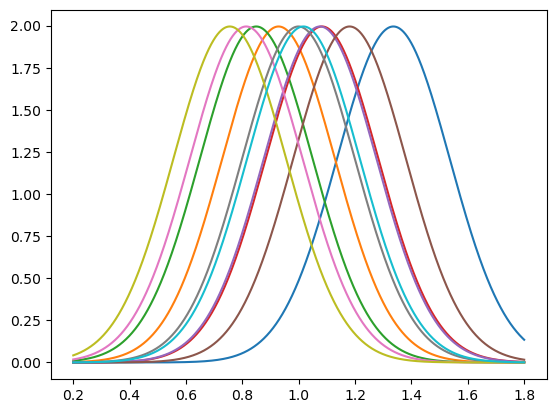

In [16]:
prod = np.ones(len(xgrid))

for xi in x:
    gauss_i = norm(xi, sigma)
    like_i = gauss_i.pdf(xgrid)
    plt.plot(xgrid, like_i)
    
    for k in range(len(xgrid)):
        prod[k]*=like_i[k]

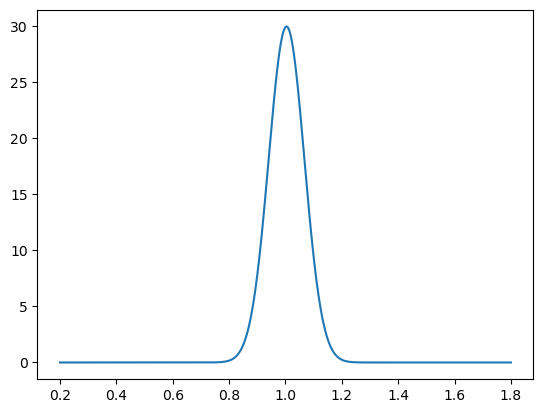

In [17]:
plt.plot(xgrid, prod)

In [18]:
mle_idx = np.argmax(prod)
mle = xgrid[mle_idx]
mle_estim = np.mean(x)
print('likelihood maximized at:',mle, 'sample mean:', mle_estim)
print('relative error:',np.abs(mle-mle_estim)/mle)

likelihood maximized at: 1.0037603760376037 sample mean: 1.0037179295455116
relative error: 4.228747528331694e-05


### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 

In [19]:
logl = np.log(prod) 
diff_logl = -(np.diff(logl, 2)/(xgrid[1]-xgrid[0])**2)[mle_idx] # diff has steps of width 1
f_s = 1./np.sqrt(diff_logl)

fish_err = sigma/np.sqrt(N)

print('Fisher error on estimated mean:', f_s)
print('Error on the mean:', fish_err)
print(np.abs(f_s-fish_err)/f_s)

Fisher error on estimated mean: 0.0632455532050095
Error on the mean: 0.06324555320336758
2.5961077509808225e-11


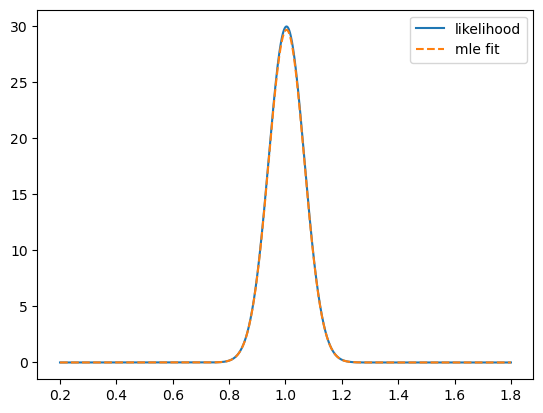

In [24]:
mle_gauss = norm(mle_estim, f_s)
mle_pdf = mle_gauss.pdf(xgrid)

plt.plot(xgrid, prod, label = 'likelihood')
plt.plot(xgrid, 4.7*mle_pdf, ls = '--', label = 'mle fit')

plt.legend()

### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

In [25]:
sig_dist = norm(0.2, 0.05)
sigmas = sig_dist.rvs(N)

x = []

for sigma in sigmas:
    gauss = norm(mu, sigma)
    x.append(gauss.rvs(1))


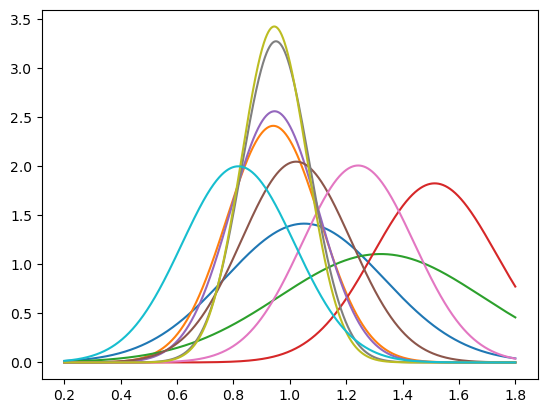

In [26]:
prod = np.ones(len(xgrid))

for xi,s in zip(x,sigmas):
    gauss_i = norm(xi, s)
    like_i = gauss_i.pdf(xgrid)
    plt.plot(xgrid, like_i)
        
    for k in range(len(xgrid)):
        prod[k]*=like_i[k]

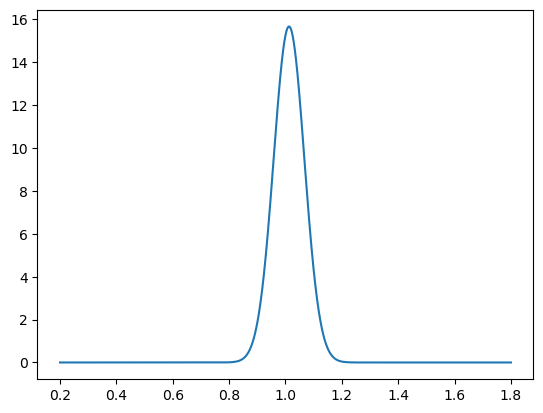

In [27]:
plt.plot(xgrid, prod)

In [28]:
mle_idx = np.argmax(prod)
mle = xgrid[mle_idx]
mle_estim = np.mean(x)
print('likelihood maximized at:', mle, 'sample mean:', mle_estim)
print('relative error:',np.abs(mle-mle_estim)/mle)

likelihood maximized at: 1.0125612561256125 sample mean: 1.0751276092325945
relative error: 0.061790190695604076
